# Deep Reinforcement Lerning Lectures - Policy Gradients

### Imports and auxiliary settings

In [46]:
# -------- OS / Colab detection --------
import os
import sys
import platform
import subprocess


In [47]:
%matplotlib inline

# PyTorch imports
import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Normal
from torch.utils.data import Dataset, DataLoader

# Cross-framework library for DL
import onnx
from onnx2pytorch import ConvertModel

# Auxiliary Python imports
import math
import io
import base64
import random
import shutil
import copy
import glob
from time import time, strftime, sleep
import numpy as np
from tqdm.notebook import tqdm

# Environment imports
import gymnasium as gym
from gymnasium.spaces import Box
from gymnasium import logger as gymlogger
from gymnasium.wrappers import RecordVideo
gymlogger.min_level = gymlogger.ERROR

# Plotting and notebook imports
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
from IPython.display import HTML, display, clear_output

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


### Auxiliary Methods

In [48]:
class Logger(object):
    """Logger that can be used for debugging different values
    """
    def __init__(self, logdir, params=None, debug=False):
        self.gradients = []
        self.debug = debug
        self.basepath = os.path.join(logdir, strftime("%Y-%m-%dT%H-%M-%S"))
        os.makedirs(self.basepath, exist_ok=True)
        os.makedirs(self.log_dir, exist_ok=True)
        if params is not None and os.path.exists(params):
            shutil.copyfile(params, os.path.join(self.basepath, "params.pkl"))
        self.log_dict = {}
        self.dump_idx = {}

    def add_gradients(self, grad):
        if not self.debug: return
        self.gradients.append(grad)

    def compute_gradient_variance(self):
        vars_ = []
        grads_list = [np.zeros_like(self.gradients[0])] * 100
        for i, grads in enumerate(self.gradients):
            grads_list.append(grads)
            grads_list = grads_list[1:]
            grad_arr = np.stack(grads_list, axis=0)
            g = np.apply_along_axis(grad_variance, axis=-1, arr=grad_arr)
            vars_.append(np.mean(g))
        return vars_

    @property
    def param_file(self):
        return os.path.join(self.basepath, "params.pkl")

    @property
    def onnx_file(self):
        return os.path.join(self.basepath, "model.onnx")

    @property
    def video_dir(self):
        return os.path.join(self.basepath, "videos")

    @property
    def log_dir(self):
        return os.path.join(self.basepath, "logs")

    def log(self, name, value):
        if name not in self.log_dict:
            self.log_dict[name] = []
            self.dump_idx[name] = -1
        self.log_dict[name].append((len(self.log_dict[name]), time(), value))

    def get_values(self, name):
        if name in self.log_dict:
            return [x[2] for x in self.log_dict[name]]
        return None

    def dump(self):
        for name, rows in self.log_dict.items():
            with open(os.path.join(self.log_dir, name + ".log"), "a") as f:
                for i, row in enumerate(rows):
                    if i > self.dump_idx[name]:
                        f.write(",".join([str(x) for x in row]) + "\n")
                        self.dump_idx[name] = i

In [49]:
def wrap_env(env, logger, capture_video=True):
    # wrapper for recording
    env = gym.wrappers.RecordEpisodeStatistics(env)
    if capture_video:
        env = gym.wrappers.RecordVideo(env, logger.video_dir, episode_trigger=lambda idx: True)
    return env


def create_env(logger, env_id='BipedalWalker-v3', hardcore=False, capture_video=True):
    # initialize single environment (for testing/evaluation)
    env = wrap_env(gym.make(env_id, max_episode_steps=800, hardcore=hardcore, render_mode="rgb_array"),
                   logger=logger,
                   capture_video=capture_video)
    action_size = env.action_space.shape[0]
    state_size = env.observation_space.shape[0]
    return env, action_size, state_size


def create_vec_env(num_envs, env_id='BipedalWalker-v3', hardcore=False, seed=42):
    """Create vectorized environments with different seeds for parallel rollouts"""
    def make_env(env_seed):
        def _init():
            env = gym.make(env_id, max_episode_steps=800, hardcore=hardcore)
            env.reset(seed=env_seed)
            return env
        return _init
    
    # Create sync vector environment (faster for CPU, simpler)
    envs = gym.vector.SyncVectorEnv([make_env(seed + i) for i in range(num_envs)])
    action_size = envs.single_action_space.shape[0]
    state_size = envs.single_observation_space.shape[0]
    return envs, action_size, state_size


def set_seed(env, seed=None):
    # seeding the envrionment
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed(seed)
            torch.cuda.manual_seed_all(seed)


def transforms(state):
    # transform to numpy to tensor and push to device
    return torch.FloatTensor(state).to(device)


def test_environment(env, agent=None, seed=42, n_steps=200):
    # run and evaluate in the environment
    state, info = env.reset(seed=seed)
    for i in range(n_steps):
        env.render()

        if agent is None:
            action = env.action_space.sample()
        else:
            action, _ = agent.act(state)
            action = action.squeeze().cpu().numpy()
        state, reward, done, truncated, info = env.step(action)
        if done:
            state, info = env.reset(seed=seed)
    env.close()


def get_running_stat(stat, stat_len):
    # evaluate stats
    cum_sum = np.cumsum(np.insert(stat, 0, 0))
    return (cum_sum[stat_len:] - cum_sum[:-stat_len]) / stat_len


def plot_results(runner):
    # plot stats
    episode, r, l = np.array(runner.stats_rewards_list).T
    cum_r = get_running_stat(r, 10)
    cum_l = get_running_stat(l, 10)

    plt.figure(figsize=(16, 16))

    plt.subplot(321)

    # plot rewards
    plt.plot(episode[-len(cum_r):], cum_r)
    plt.plot(episode, r, alpha=0.5)
    plt.xlabel('Episode')
    plt.ylabel('Episode Reward')

    plt.subplot(322)

    # plot episode lengths
    plt.plot(episode[-len(cum_l):], cum_l)
    plt.plot(episode, l, alpha=0.5)
    plt.xlabel('Episode')
    plt.ylabel('Episode Length')

    plt.subplot(323)

    # plot return
    all_returns = np.array(runner.buffer.all_returns)
    plt.scatter(range(0, len(all_returns)), all_returns, alpha=0.5)
    mean_returns = np.array(runner.buffer.mean_returns)
    plt.plot(range(0, len(mean_returns)), mean_returns, color="orange")
    plt.xlabel('Episode')
    plt.ylabel('Return')

    plt.subplot(324)

    # plot entropy
    entropy_arr = np.array(runner.stats_entropy_list)
    plt.plot(range(0, len(entropy_arr)), entropy_arr)
    plt.xlabel('Episode')
    plt.ylabel('Entropy')

    plt.subplot(325)

    if runner.logger.debug:
        # plot variance
        variance_arr = np.array(runner.logger.compute_gradient_variance())
        plt.plot(range(0, len(variance_arr)), variance_arr)
        plt.xlabel('Episode')
        plt.ylabel('Variance')

    plt.show()


"""
Utility functions to enable video recording of gym environment and displaying it
"""
def show_video(logger):
    print(logger.video_dir)
    mp4list = glob.glob(f'{logger.video_dir}/*.mp4')
    if len(mp4list) > 0:
        mp4 = mp4list[0]
        video = io.open(mp4, 'r+b').read()
        encoded = base64.b64encode(video)
        display(HTML(data='''<video alt="test" autoplay
                  loop controls style="height: 400px;">
                  <source src="data:video/mp4;base64,{0}" type="video/mp4" />
                </video>'''.format(encoded.decode('ascii'))))
    else:
        print("Could not find video")


def grad_variance(g):
    # compute gradient variance
    return np.mean(g**2) - np.mean(g)**2

### Test environment

OpenAI offers a set of environments for Reinforcement Learning, which are accessible via the `gymnasium` pip package.
In this exercise we will focus on discrete control tasks using a Box2D simulation known as BipedalWalker-v3.
To access the Box2D packages, we use the gymnasium pypi `box2d` option.

In [50]:
# show behavior in envrionment with random agent
logger = Logger("logdir")
env, _, _ = create_env(logger)
test_environment(env)
show_video(logger)

logdir/2026-05-06T19-54-40/videos


### Training Buffer

In [ ]:
class Transition(object):
    """Transition helper object
    """
    def __init__(self, state, action, reward, next_state, log_probs, value=0.0):
        self.state = state
        self.action = action
        self.reward = reward
        self.next_state = next_state
        self.g_return = 0.0
        self.log_probs = log_probs
        self.value = value  # value estimate
        self.advantage = 0.0  # GAE advantage
        self.value_target = 0.0  # value target 

class Episode(object):
    """Class for collecting an episode of transitions
    """
    def __init__(self, discount, gae_lambda=0.95):
        self.discount = discount
        self.gae_lambda = gae_lambda
        self._empty()
        self.total_reward = 0.0

    def _empty(self):
        self.n = 0
        self.transitions = []

    def reset(self):
        self._empty()

    def size(self):
        return self.n

    def append(self, transition):
        self.transitions.append(transition)
        self.n += 1

    def states(self):
        return [s.state for s in self.transitions]

    def actions(self):
        return [a.action for a in self.transitions]

    def rewards(self):
        return [r.reward for r in self.transitions]

    def next_states(self):
        return [s_.next_state for s_ in self.transitions]

    def returns(self):
        return [r.g_return for r in self.transitions]

    def calculate_return(self):
        # calculate the return of the episode
        rewards = self.rewards()
        trajectory_len = len(rewards)
        return_array = torch.zeros((trajectory_len,))
        g_return = 0.
        for i in range(trajectory_len-1, -1, -1):
            g_return = float(rewards[i]) + self.discount * g_return
            return_array[i] = float(g_return)
            self.transitions[i].g_return = float(g_return)
        return return_array

    def calculate_gae(self, last_value=0.0):
        """Calculate Generalized Advantage Estimation (GAE)
        """
        trajectory_len = len(self.transitions)
        gae = 0.0
        
        for i in range(trajectory_len - 1, -1, -1):
            t = self.transitions[i]
            
            if i == trajectory_len - 1:
                next_value = last_value
            else:
                next_value = self.transitions[i + 1].value
            
            delta = float(t.reward) + self.discount * next_value - t.value
            gae = delta + self.discount * self.gae_lambda * gae
            
            t.advantage = gae
            t.value_target = gae + t.value  


class BufferDataset(Dataset):
    """Buffer dataset used to iterate over buffer samples when training.
    """
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        t = self.data[idx]
        return t.state, t.action, t.advantage, t.value_target, t.log_probs


class RolloutBuffer(object):
    # ===================================================
    # ++++++++++++++++++++ OPTIONAL +++++++++++++++++++++
    # ===================================================
    # > feel free to optimize sampling and buffer handling
    # ===================================================
    """Buffer to collect samples while rolling out in the envrionment.
    """
    def __init__(self, capacity, batch_size, min_transitions):
        self.capacity = capacity
        self.batch_size = batch_size
        self.min_transitions = min_transitions
        self.buffer = []
        self._empty()
        self.mean_returns = []
        self.all_returns = []

    def _empty(self):
        # empty the buffer
        del self.buffer[:]
        self.position = 0

    def add(self, episode, last_value=0.0):
        episode.calculate_return()
        episode.calculate_gae(last_value=last_value)
        for t in episode.transitions:
            if len(self.buffer) < self.capacity:
                self.buffer.append(None)
            self.buffer[self.position] = t
            self.position = (self.position + 1) % self.capacity

    def update_stats(self):
        # update the statistics on the buffer
        returns = [t.g_return for t in self.buffer]
        self.all_returns += returns
        mean_return = np.mean(np.array(returns))
        self.mean_returns += ([mean_return]*len(returns))

    def reset(self):
        # calls empty
        self._empty()

    def create_dataloader(self):
        # creates a dataloader for training
        train_loader = DataLoader(
            BufferDataset(self.buffer),
            batch_size=self.batch_size,
            shuffle=True
        )
        return train_loader

    def __len__(self):
        return len(self.buffer)

### Define Models

In [ ]:
class ActorNet(nn.Module):
    """Actor network (policy)
    
    NOTE: forward() outputs RAW LOGITS to be compatible with gym_evaluation_script_ppo.py
    The eval script applies F.tanh(mu_logits) and F.softplus(sigma_logits) + 1e-5
    """
    def __init__(self, state_size, action_size, hidden_size):
        super(ActorNet, self).__init__()
        self.fc1 = nn.Linear(state_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.mu_head = nn.Linear(hidden_size, action_size)
        # Learnable sigma logits - will be softplussed by consumer
        # Initialize so that softplus(0) + 1e-5 ≈ 0.693 (reasonable starting std)
        self.sigma_logits = nn.Parameter(torch.zeros(action_size))
        
        # Orthogonal initialization - CRITICAL for PPO
        nn.init.orthogonal_(self.fc1.weight, gain=np.sqrt(2))
        nn.init.orthogonal_(self.fc2.weight, gain=np.sqrt(2))
        nn.init.orthogonal_(self.mu_head.weight, gain=0.01)
        nn.init.zeros_(self.fc1.bias)
        nn.init.zeros_(self.fc2.bias)
        nn.init.zeros_(self.mu_head.bias)

    def forward(self, x):
        """Returns RAW LOGITS for compatibility with eval script"""
        x = torch.tanh(self.fc1(x))
        x = torch.tanh(self.fc2(x))
        mu_logits = self.mu_head(x)  # Raw logits (eval script applies tanh)
        # Expand sigma_logits to match batch size
        sigma_logits = self.sigma_logits.expand(x.shape[0], -1)
        return mu_logits, sigma_logits


class CriticNet(nn.Module):
    """Critic network computing the state value
    """
    def __init__(self, state_size, action_size, hidden_size):
        super(CriticNet, self).__init__()
        self.fc1 = nn.Linear(state_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.value_head = nn.Linear(hidden_size, 1)
        
        # Orthogonal initialization for critic too!
        nn.init.orthogonal_(self.fc1.weight, gain=np.sqrt(2))
        nn.init.orthogonal_(self.fc2.weight, gain=np.sqrt(2))
        nn.init.orthogonal_(self.value_head.weight, gain=1.0)
        nn.init.zeros_(self.fc1.bias)
        nn.init.zeros_(self.fc2.bias)
        nn.init.zeros_(self.value_head.bias)

    def forward(self, x):
        x = torch.tanh(self.fc1(x))
        x = torch.tanh(self.fc2(x))
        value = self.value_head(x)
        return value


class ActorCriticNet(nn.Module):
    """Combining both networks and add helper methods to act and evaluate samples.
    """
    def __init__(self, state_size, action_size, hidden_size):
        super(ActorCriticNet, self).__init__()
        self.actor = ActorNet(state_size, action_size, hidden_size)
        self.critic = CriticNet(state_size, action_size, hidden_size)

    def forward(self, x):
        """Forward pass returns raw logits for ONNX export compatibility"""
        x = x.reshape(1, -1)
        return self.actor(x)

    def _get_distribution(self, state):
        """Get distribution from actor output (applies same transforms as eval script)"""
        mu_logits, sigma_logits = self.actor(state)
        # Apply same transformations as gym_evaluation_script_ppo.py
        mu = torch.tanh(mu_logits)
        sigma = F.softplus(sigma_logits) + 1e-5
        return Normal(mu, sigma)

    def act(self, state):
        dist = self._get_distribution(state)
        action = dist.sample()
        # Clamp action to valid range
        action_clamped = torch.clamp(action, -1.0, 1.0)
        # Compute log_prob for the CLAMPED action (what we actually execute)
        log_probs = dist.log_prob(action_clamped).sum(dim=-1)  # Shape: [batch]
        return action_clamped, log_probs

    def evaluate(self, state, action):
        dist = self._get_distribution(state)
        log_probs = dist.log_prob(action).sum(dim=-1)  # Shape: [batch]
        entropy = dist.entropy().sum(dim=-1)  # Shape: [batch]
        value = self.critic(state)
        return log_probs, entropy, value

### Define Agent

In [ ]:
class Agent(object):
    """Agent class used for training, saving data and handling the model.
    """
    def __init__(self, buffer, state_size, action_size, hidden_size, learning_rate, logger, eps_clip, n_epochs,
                 weight_decay, betas, loss_scales, discount, gae_lambda=0.95, checkpoint_dir="ckpts"):
        self.action_size = action_size
        self.state_size = state_size
        self.buffer = buffer
        self.checkpoint_dir = checkpoint_dir
        self.loss_scales = loss_scales
        self.n_epochs = n_epochs
        self.eps_clip = eps_clip
        self.logger = logger
        self.discount = discount
        self.gae_lambda = gae_lambda
        
        self.model = ActorCriticNet(state_size, action_size, hidden_size).to(device)
        self.initial_lr = learning_rate
        self.optimizer = optim.Adam(self.model.parameters(), lr=learning_rate, 
                                    betas=betas, weight_decay=weight_decay, eps=1e-5)

    def set_learning_rate(self, progress):
        """Linear learning rate annealing: lr = initial_lr * (1 - progress)"""
        lr = self.initial_lr * (1.0 - progress)
        for param_group in self.optimizer.param_groups:
            param_group['lr'] = lr
        return lr

    def update_obs_stats(self, state):
        """Update observation statistics"""
        if isinstance(state, torch.Tensor):
            state_np = state.cpu().numpy()
        else:
            state_np = np.array(state)
        self.obs_rms.update(state_np)

    def save_checkpoint(self, epoch, info=''):
        """Saves a model checkpoint"""
        state = {
            'info': info,
            'epoch': epoch,
            'state_dict': self.model.state_dict(),
            'optimizer': self.optimizer.state_dict(),
            'obs_mean': self.obs_rms.mean,
            'obs_var': self.obs_rms.var,
            'obs_count': self.obs_rms.count
        }
        os.makedirs(self.checkpoint_dir, exist_ok=True)
        ckp_name = 'best-checkpoint.pth' if info == 'best' else f'checkpoint-epoch{epoch}.pth'
        filename = os.path.join(self.checkpoint_dir, ckp_name)
        torch.save(state, filename)

    def resume_checkpoint(self, resume_path):
        """Resumes training from an existing model checkpoint"""
        print("Loading checkpoint: {} ...".format(resume_path))
        checkpoint = torch.load(resume_path)
        self.model.load_state_dict(checkpoint['state_dict'])
        self.optimizer.load_state_dict(checkpoint['optimizer'])
        if 'obs_mean' in checkpoint:
            self.obs_rms.mean = checkpoint['obs_mean']
            self.obs_rms.var = checkpoint['obs_var']
            self.obs_rms.count = checkpoint['obs_count']
        print("Checkpoint loaded. Resume training")

    def load_onnx_checkpoint(self, onnx_file):
        self.model.actor = ConvertModel(onnx.load(onnx_file)).to(device)
        self.model.eval()

    def save_onnx_checkpoint(self):
        """Create an ONNX checkpoint"""
        dummy_input = torch.randn((1, self.state_size))
        dummy_input_t = transforms(dummy_input).to(device)
        model = self.model.actor.to(device)
        torch.onnx.export(model, dummy_input_t, "submission_actor.onnx", verbose=False, opset_version=10, export_params=True, do_constant_folding=True)

    def check(self, file_name):
        # Load the ONNX model
        model = onnx.load(file_name)
        # Check that the IR is well formed
        onnx.checker.check_model(model)

    def act(self, state):
        # Use raw state (no normalization for eval script compatibility)
        state_t = transforms(state)
        if state_t.dim() == 1:
            state_t = state_t.unsqueeze(0)
        with torch.no_grad():
            action, log_probs = self.model.act(state_t)
        return action, log_probs

    def get_value(self, state):
        """Get value estimate for a state"""
        state_t = transforms(state)
        if state_t.dim() == 1:
            state_t = state_t.unsqueeze(0)
        with torch.no_grad():
            value = self.model.critic(state_t)
        return value.item()

    def train(self):
        for i in range(self.n_epochs):
            loader = self.buffer.create_dataloader()
            for states, actions, advantages, value_targets, old_log_probs in loader:
                # States are already normalized when stored
                states = states.float().to(device)
                actions = actions.float().to(device)
                advantages = advantages.float().to(device)  # Shape: [batch]
                value_targets = value_targets.float().to(device)  # Shape: [batch]
                old_log_probs = old_log_probs.float().to(device)  # Shape: [batch]
                
                # Evaluate current policy - all outputs are now [batch] (except values which is [batch, 1])
                new_log_probs, entropy, values = self.model.evaluate(states, actions)
                values = values.squeeze(-1)  # [batch, 1] -> [batch]
                
                # Normalize advantages
                if advantages.numel() > 1:
                    advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
                
                # Importance sampling ratio
                log_ratio = new_log_probs - old_log_probs
                log_ratio = torch.clamp(log_ratio, -20, 20)
                ratios = torch.exp(log_ratio)
                
                # PPO clipped objective
                surr1 = ratios * advantages
                surr2 = torch.clamp(ratios, 1 - self.eps_clip, 1 + self.eps_clip) * advantages
                policy_loss = -torch.min(surr1, surr2)
                
                # Value loss
                value_loss = F.mse_loss(values, value_targets, reduction='none')
                
                # Total loss
                value_scale, policy_scale, entropy_scale = self.loss_scales
                loss = policy_scale * policy_loss + value_scale * value_loss - entropy_scale * entropy
                
                # Backprop
                self.optimizer.zero_grad()
                loss.mean().backward()
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), 0.5)
                self.optimizer.step()

        return (loss.mean().detach().cpu().numpy(),
                value_loss.mean().detach().cpu().numpy(),
                policy_loss.mean().detach().cpu().numpy()), entropy.mean().detach().cpu().numpy()

### Define Task Runner

In [54]:
class VecRunner(object):
    """Vectorized Runner class - runs multiple environments in parallel for better sample efficiency.
    
    Key benefits:
    - Diverse experience from different seeds
    - Lower gradient variance
    - Better exploration
    - Decorrelated samples
    """
    def __init__(self, envs, agent, buffer, logger, num_envs=8, discount=0.99, gae_lambda=0.95, 
                 n_updates=1000, steps_per_env=256, reward_scale=lambda x: x, use_buffer_reset=True,
                 stats_interval=1, print_stats=True, seed=42, checkpoint_interval=10):
        self.envs = envs
        self.agent = agent
        self.buffer = buffer
        self.logger = logger
        self.num_envs = num_envs
        self.discount = discount
        self.gae_lambda = gae_lambda
        self.n_updates = n_updates  # Number of PPO updates
        self.steps_per_env = steps_per_env  # Steps to collect per env before update
        self.reward_scale = reward_scale
        self.use_buffer_reset = use_buffer_reset
        self.stats_interval = stats_interval
        self.print_stats = print_stats
        self.seed = seed
        self.checkpoint_interval = checkpoint_interval
        
        # Stats tracking
        self.stats_rewards_list = []
        self.stats_entropy_list = []
        self.timesteps = 0
        self.best_model = None
        self.max_reward = -np.inf
        self.episode_count = 0
        
        # Per-env episode tracking
        self.current_episode_rewards = np.zeros(num_envs)
        self.current_episode_lengths = np.zeros(num_envs, dtype=int)

    def run(self):
        self.agent.model.eval()
        
        # Initialize all environments
        states, _ = self.envs.reset()  # Shape: [num_envs, state_size]
        
        with tqdm(range(self.n_updates)) as pbar:
            for update in pbar:
                # Storage for this rollout
                rollout_states = []
                rollout_actions = []
                rollout_rewards = []
                rollout_dones = []
                rollout_log_probs = []
                rollout_values = []
                
                # Collect rollout from all envs in parallel
                for step in range(self.steps_per_env):
                    self.timesteps += self.num_envs
                    
                    # Get actions for all envs at once
                    states_t = transforms(states)  # [num_envs, state_size]
                    with torch.no_grad():
                        actions, log_probs = self.agent.model.act(states_t)
                        values = self.agent.model.critic(states_t).squeeze(-1)  # [num_envs]
                    
                    actions_np = actions.cpu().numpy()  # [num_envs, action_size]
                    
                    # Step all envs
                    next_states, rewards, terminateds, truncateds, infos = self.envs.step(actions_np)
                    dones = np.logical_or(terminateds, truncateds)
                    
                    # Track episode stats
                    self.current_episode_rewards += rewards
                    self.current_episode_lengths += 1
                    
                    # Store transition
                    rollout_states.append(states)
                    rollout_actions.append(actions.cpu())
                    rollout_rewards.append(self.reward_scale(rewards))
                    rollout_dones.append(dones)
                    rollout_log_probs.append(log_probs.cpu())
                    rollout_values.append(values.cpu())
                    
                    # Handle completed episodes
                    for env_idx in range(self.num_envs):
                        if dones[env_idx]:
                            ep_reward = self.current_episode_rewards[env_idx]
                            ep_length = self.current_episode_lengths[env_idx]
                            
                            self.stats_rewards_list.append((self.episode_count, ep_reward, ep_length))
                            self.logger.log("episode_reward", ep_reward)
                            self.logger.log("episode_length", ep_length)
                            
                            # Track best
                            if ep_reward > self.max_reward:
                                self.max_reward = ep_reward
                                self.best_model = copy.deepcopy(self.agent.model)
                                self.agent.save_checkpoint(self.episode_count, 'best')
                            
                            # Reset per-env tracking
                            self.current_episode_rewards[env_idx] = 0
                            self.current_episode_lengths[env_idx] = 0
                            self.episode_count += 1
                    
                    states = next_states
                
                # Compute last values for GAE (bootstrap)
                with torch.no_grad():
                    last_values = self.agent.model.critic(transforms(states)).squeeze(-1).cpu().numpy()
                
                # Convert to arrays
                rollout_states = np.array(rollout_states)  # [steps, num_envs, state_size]
                rollout_actions = torch.stack(rollout_actions)  # [steps, num_envs, action_size]
                rollout_rewards = np.array(rollout_rewards)  # [steps, num_envs]
                rollout_dones = np.array(rollout_dones)  # [steps, num_envs]
                rollout_log_probs = torch.stack(rollout_log_probs)  # [steps, num_envs]
                rollout_values = torch.stack(rollout_values).numpy()  # [steps, num_envs]
                
                # Compute GAE for all envs
                advantages, value_targets = self._compute_gae(
                    rollout_rewards, rollout_values, rollout_dones, last_values
                )
                
                # Flatten for training: [steps * num_envs, ...]
                flat_states = rollout_states.reshape(-1, rollout_states.shape[-1])
                flat_actions = rollout_actions.reshape(-1, rollout_actions.shape[-1])
                flat_log_probs = rollout_log_probs.reshape(-1)
                flat_advantages = advantages.reshape(-1)
                flat_value_targets = value_targets.reshape(-1)
                flat_values = rollout_values.reshape(-1)
                
                # Add to buffer as individual transitions
                self.buffer.reset()
                for i in range(len(flat_states)):
                    t = Transition(
                        state=transforms(flat_states[i]),
                        action=flat_actions[i],
                        reward=0,  # Not used
                        next_state=None,  # Not used
                        log_probs=flat_log_probs[i],
                        value=flat_values[i]
                    )
                    t.advantage = flat_advantages[i]
                    t.value_target = flat_value_targets[i]
                    if len(self.buffer.buffer) < self.buffer.capacity:
                        self.buffer.buffer.append(t)
                    else:
                        self.buffer.buffer[self.buffer.position] = t
                    self.buffer.position = (self.buffer.position + 1) % self.buffer.capacity
                
                # Learning rate annealing (linear decay)
                progress = update / self.n_updates
                current_lr = self.agent.set_learning_rate(progress)
                
                # Train on collected data
                self.buffer.update_stats()
                self.agent.model.train()
                losses, entropy = self.agent.train()
                self.agent.model.eval()
                
                total_loss, value_loss, policy_loss = losses
                self.stats_entropy_list.append(entropy)
                
                self.logger.log("total_loss", total_loss)
                self.logger.log("value_loss", value_loss)
                self.logger.log("policy_loss", policy_loss)
                self.logger.log("entropy", entropy)
                
                # Checkpoint
                if update % self.checkpoint_interval == 0:
                    self.agent.save_checkpoint(update)
                
                # Progress display
                if self.print_stats and update % self.stats_interval == 0:
                    recent_rewards = [r[1] for r in self.stats_rewards_list[-10:]] if self.stats_rewards_list else [0]
                    avg_reward = np.mean(recent_rewards)
                    pbar.set_postfix({
                        'avg_reward': f'{avg_reward:.1f}',
                        'best': f'{self.max_reward:.1f}',
                        'episodes': self.episode_count,
                        'lr': f'{current_lr:.2e}'
                    })
                
                self.logger.dump()
        
        print(f"\nTraining complete! Episodes: {self.episode_count}, Best reward: {self.max_reward:.2f}")

    def _compute_gae(self, rewards, values, dones, last_values):
        """Compute GAE for vectorized environments"""
        steps, num_envs = rewards.shape
        advantages = np.zeros_like(rewards)
        
        gae = np.zeros(num_envs)
        for t in reversed(range(steps)):
            if t == steps - 1:
                next_values = last_values
                next_non_terminal = 1.0 - dones[t].astype(float)
            else:
                next_values = values[t + 1]
                next_non_terminal = 1.0 - dones[t].astype(float)
            
            # TD error
            delta = rewards[t] + self.discount * next_values * next_non_terminal - values[t]
            # GAE
            gae = delta + self.discount * self.gae_lambda * next_non_terminal * gae
            advantages[t] = gae
        
        value_targets = advantages + values
        return advantages, value_targets


# Keep original Runner for backward compatibility / single env testing
class Runner(object):
    """Single-env Runner class (legacy, for testing)"""
    def __init__(self, env, agent, buffer, logger, discount=0.99, gae_lambda=0.95, n_episodes=4000, reward_scale=lambda x: x,
                 use_buffer_reset=True, stats_interval=1, print_stats=True, min_average_reward=300, render=False, seed=42, checkpoint_interval=100, max_episode_steps=2000):
        self.env = env
        self.agent = agent
        self.buffer = buffer
        self.render = render
        self.logger = logger
        self.discount = discount
        self.gae_lambda = gae_lambda
        self.n_episodes = n_episodes
        self.reward_scale = reward_scale
        self.use_buffer_reset = use_buffer_reset
        self.stats_interval = stats_interval
        self.print_stats = print_stats
        self.min_average_reward = min_average_reward
        self.seed = seed
        self.max_episode_steps = max_episode_steps
        # store stats for plotting
        self.stats_rewards_list = []
        self.stats_entropy_list = []
        # stats for running episodes
        self.timesteps = 0
        self.checkpoint_interval = checkpoint_interval
        self.best_model = None
        self.max_reward = -np.inf

    def run(self):
        self.agent.model.eval()
        # train for n episodes
        with tqdm(range(self.n_episodes)) as pbar:
            for e in pbar:
                # Random initial states - critical for generalization
                state, info = self.env.reset()
                total_losses = 0.
                value_losses = 0.
                policy_losses = 0.

                # create new episode with GAE lambda
                episode = Episode(discount=self.discount, gae_lambda=self.gae_lambda)

                # save model
                if e % self.checkpoint_interval == 0:
                    self.agent.save_checkpoint(e)

                done = False
                while not done:
                    self.timesteps += 1
                    if self.render: self.env.render()

                    # Get action, log_probs, and value (agent handles normalization internally)
                    action, log_probs = self.agent.act(state)
                    value = self.agent.get_value(state)
                    action_np = action.squeeze().cpu().numpy()
                    
                    # Step in environment
                    next_state, reward, terminated, truncated, info = self.env.step(action_np)
                    done = terminated or truncated
                    
                    # Store raw state in transition (no normalization for eval script compatibility)
                    scaled_reward = self.reward_scale(reward)
                    transition = Transition(
                        state=transforms(state),
                        action=action.squeeze(),
                        reward=scaled_reward,
                        next_state=transforms(next_state),
                        log_probs=log_probs.squeeze(),
                        value=value
                    )
                    episode.append(transition)
                    episode.total_reward += reward
                    
                    state = next_state
                
                # Compute last value for GAE
                if truncated:
                    last_value = self.agent.get_value(next_state)
                else:
                    last_value = 0.0
                
                # Add episode to buffer
                self.buffer.add(episode, last_value=last_value)
                
                # Update when buffer is full
                if len(self.buffer) >= self.buffer.min_transitions:
                    self.buffer.update_stats()
                    self.agent.model.train()
                    losses, entropy = self.agent.train()
                    self.agent.model.eval()
                    
                    total_losses, value_losses, policy_losses = losses
                    self.stats_entropy_list.append(entropy)
                    
                    self.logger.log("total_loss", total_losses)
                    self.logger.log("value_loss", value_losses)
                    self.logger.log("policy_loss", policy_losses)
                    self.logger.log("entropy", entropy)
                    
                    if self.use_buffer_reset:
                        self.buffer.reset()
                
                # Log episode stats
                self.stats_rewards_list.append((e, episode.total_reward, episode.size()))
                self.logger.log("episode_reward", episode.total_reward)
                self.logger.log("episode_length", episode.size())
                
                if self.print_stats and e % self.stats_interval == 0:
                    pbar.set_postfix({
                        'reward': f'{episode.total_reward:.2f}',
                        'length': episode.size(),
                        'best': f'{self.max_reward:.2f}'
                    })
                
                self.logger.dump()

                # save best model
                if self.best_model is None or episode.total_reward > self.max_reward:
                    self.best_model = copy.deepcopy(self.agent.model)
                    self.agent.save_checkpoint(e, 'best')
                    self.max_reward = episode.total_reward

### Train Agent

This is a where you run your actor-critic PPO algorithm.

Some tips as to what you need to implement:
- chose proper architectures for the actor-critic networks
- choose the appropriate loss function (think on which kind of problem you are solving)
- choose an optimizer and its hyper-parameters
- optional: use a learning-rate scheduler
- store your model and training progress often so you don't loose progress if your program crashes

In case you use the provided Logger:
- `logger.log("training_loss", <loss-value>)` to log a particular value
- `logger.dump()` to write the current logs to a log file (e.g. after every episode)
- `logger.log_dir`, `logger.param_file`, `logger.onnx_file`, `logger.video_dir` point to files or directories you can use to save files
- you might want to specify your google drive folder as a logdir in order to automatically sync your results
- if you log the metrics specified in the `plot_metrics` function you can use it to visualize your training progress (or take it as a template to plot your own metrics)

In [ ]:
# ===================================================
# VECTORIZED PPO HYPERPARAMETERS FOR BIPEDALWALKER
# ===================================================
seed = 42
set_seed(None, seed=seed)

# Environment settings
num_envs = 12  # Number of parallel environments (key for performance!)
logger = Logger("logdir")
envs, action_size, state_size = create_vec_env(num_envs=num_envs, seed=seed)

# Training schedule
n_updates = 1000 # Number of PPO updates
steps_per_env = 256  # Steps per env per update (total: 12 * 256 = 3072 per update)
epochs = 10  # PPO epochs per update

# Network
hidden_size = 256

# PPO hyperparameters
learning_rate = 5e-4
discount = 0.99
gae_lambda = 0.95
eps_clip = 0.2
loss_scales = (0.5, 1.0, 0.01)  # (value_coef, policy_coef, entropy_coef)

# Optimizer
betas = (0.9, 0.999)
weight_decay = 0.0

# Buffer
batch_size = 64
min_transitions = num_envs * steps_per_env  # 2048
capacity = min_transitions * 2

# Misc
reward_scale = lambda x: x / 1.5
checkpoint_interval = 50
print_stats = True

print(f"State size: {state_size}, Action size: {action_size}")
print(f"Parallel envs: {num_envs}, Steps/env: {steps_per_env}")
print(f"Total steps per update: {num_envs * steps_per_env}")

State size: 24, Action size: 4
Parallel envs: 12, Steps/env: 256
Total steps per update: 3072


In [56]:
buffer = RolloutBuffer(capacity=capacity, batch_size=batch_size, min_transitions=min_transitions)
agent = Agent(buffer=buffer, state_size=state_size, action_size=action_size, hidden_size=hidden_size,
              learning_rate=learning_rate, logger=logger, eps_clip=eps_clip, n_epochs=epochs, 
              weight_decay=weight_decay, betas=betas, loss_scales=loss_scales, discount=discount, 
              gae_lambda=gae_lambda)

# Use VecRunner for parallel environment training
runner = VecRunner(
    envs=envs, agent=agent, buffer=buffer, logger=logger,
    num_envs=num_envs, discount=discount, gae_lambda=gae_lambda,
    n_updates=n_updates, steps_per_env=steps_per_env,
    reward_scale=reward_scale, use_buffer_reset=True,
    print_stats=print_stats, seed=seed, checkpoint_interval=checkpoint_interval
)

print(f"State size: {state_size}, Action size: {action_size}")
print(f"Total parameters: {sum(p.numel() for p in agent.model.parameters())}")
print(f"Using VecRunner with {num_envs} parallel environments")

State size: 24, Action size: 4
Total parameters: 145673
Using VecRunner with 12 parallel environments


In [57]:
runner.run()

  0%|          | 0/1000 [00:00<?, ?it/s]


Training complete! Episodes: 4068, Best reward: 225.17


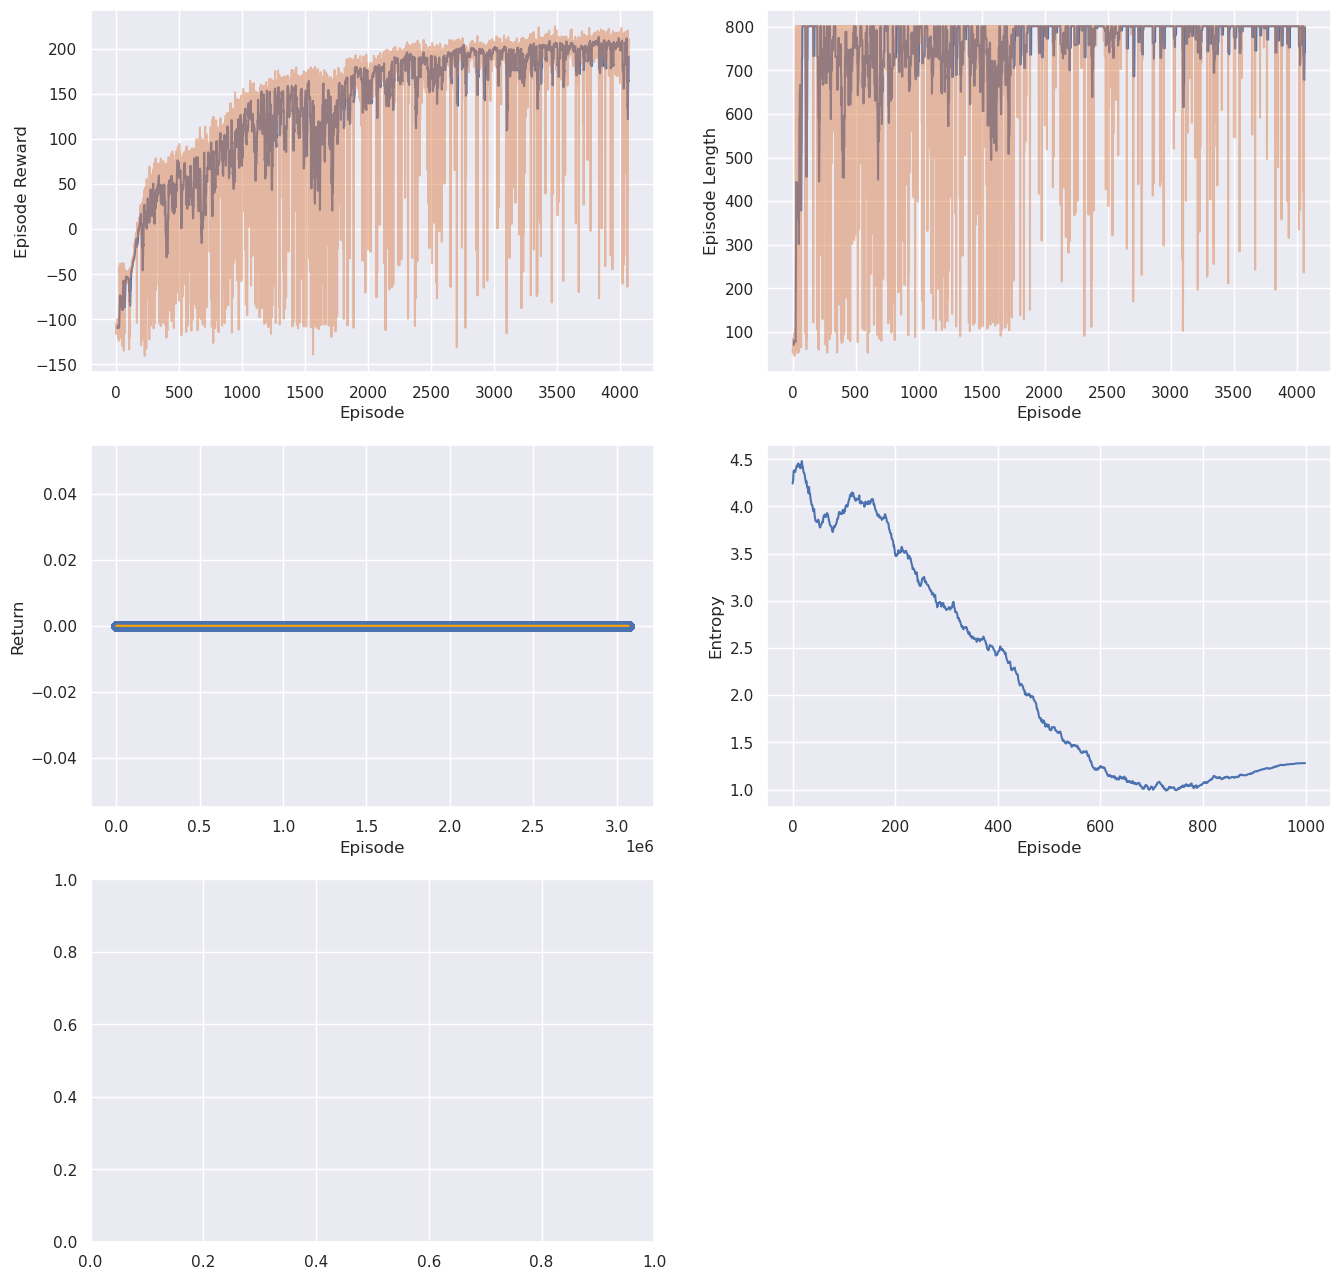

In [58]:
plot_results(runner)

In [59]:
agent.save_onnx_checkpoint()

/tmp/ipykernel_11950/1474543582.py:90: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(model, dummy_input_t, "submission_actor.onnx", verbose=False, opset_version=10, export_params=True, do_constant_folding=True)


## Visualize Agent

In [60]:
# load model from checkpoint
agent.resume_checkpoint('ckpts/best-checkpoint.pth')

Loading checkpoint: ckpts/best-checkpoint.pth ...


UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy._core.multiarray._reconstruct was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy._core.multiarray._reconstruct])` or the `torch.serialization.safe_globals([numpy._core.multiarray._reconstruct])` context manager to allowlist this global if you trust this class/function.

Check the documentation of to

In [ ]:
# run agent in the envrionment
env, _, _ = create_env(logger)
agent.model.eval()
test_environment(env=env, agent=agent)
show_video(logger)

logdir/2026-05-05T17-46-03/videos


# Demo Evaluations

In [ ]:
agent.load_onnx_checkpoint('submission_actor.onnx')

In [ ]:
# run agent in the envrionment
logger = Logger('logdir')
env, _, _ = create_env(logger)
agent.model.eval()
test_environment(env=env, agent=agent, n_steps=500)
show_video(logger)

logdir/2026-05-05T18-36-15/videos
